In [1]:
import numpy as np

X_emb = np.load("/home/pasquale/PycharmProjects/Glomeruli-FP03-2026/data/glomeruli/embeddings/dinov2_large_cls_masked_embeddings.npy")

feature_std = np.std(X_emb, axis=0)

print("mean:", feature_std.mean())
print("min:", feature_std.min())
print("max:", feature_std.max())

print("dead <1e-6:", np.sum(feature_std < 1e-6))
print("dead <1e-4:", np.sum(feature_std < 1e-4))
print("dead <1e-3:", np.sum(feature_std < 1e-3))

mean: 0.30538592
min: 0.03328992
max: 0.8533238
dead <1e-6: 0
dead <1e-4: 0
dead <1e-3: 0


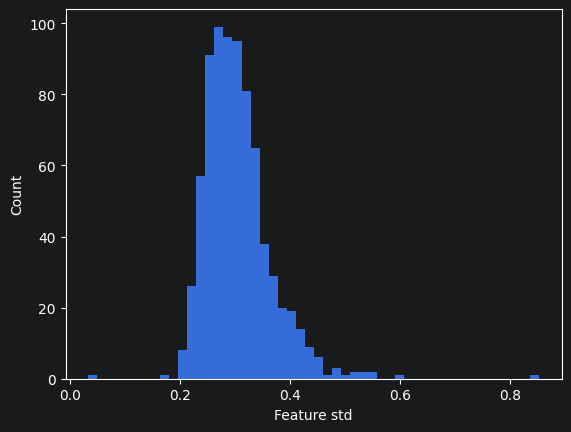

In [2]:
import matplotlib.pyplot as plt

plt.hist(feature_std, bins=50)
plt.xlabel("Feature std")
plt.ylabel("Count")
plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image


def inspect_most_variable_feature(
    X_emb: np.ndarray,
    image_paths,
    top_n: int = 10,
    figsize=(14, 5),
):
    """
    Ispeziona la feature dell'embedding con deviazione standard massima.

    Parametri
    ----------
    X_emb : np.ndarray
        Matrice degli embedding, shape = (n_samples, n_features).

    image_paths : list-like
        Lista dei path delle immagini, nello stesso ordine degli embedding.

    top_n : int
        Numero di immagini da mostrare tra valori più bassi e più alti.

    figsize : tuple
        Dimensione della figura matplotlib.

    Ritorna
    -------
    result : dict
        Dizionario con:
        - indice della feature più variabile
        - std massima
        - indici top_low
        - indici top_high
        - valori top_low
        - valori top_high
    """

    X_emb = np.asarray(X_emb)

    if X_emb.ndim != 2:
        raise ValueError("X_emb deve avere shape (n_samples, n_features).")

    if len(image_paths) != X_emb.shape[0]:
        raise ValueError(
            f"Numero immagini ({len(image_paths)}) diverso dal numero embedding ({X_emb.shape[0]})."
        )

    # 1. Deviazione standard di ogni feature
    feature_std = np.std(X_emb, axis=0)

    # 2. Feature più variabile
    idx_max = int(np.argmax(feature_std))
    max_std = float(feature_std[idx_max])

    print("Feature con std massima:", idx_max)
    print("Std massima:", max_std)

    # 3. Valori della feature più variabile per tutti i campioni
    values = X_emb[:, idx_max]

    # Indici delle immagini con valore più basso e più alto
    top_low = np.argsort(values)[:top_n]
    top_high = np.argsort(values)[-top_n:][::-1]

    print("\nValori più bassi:")
    for idx in top_low:
        print(f"index={idx}, value={values[idx]:.6f}, path={image_paths[idx]}")

    print("\nValori più alti:")
    for idx in top_high:
        print(f"index={idx}, value={values[idx]:.6f}, path={image_paths[idx]}")

    # 4. Plot immagini con valori più bassi
    _plot_image_grid(
        image_paths=image_paths,
        indices=top_low,
        values=values,
        title=f"Feature {idx_max} - valori più bassi",
        figsize=figsize,
    )

    # 5. Plot immagini con valori più alti
    _plot_image_grid(
        image_paths=image_paths,
        indices=top_high,
        values=values,
        title=f"Feature {idx_max} - valori più alti",
        figsize=figsize,
    )

    result = {
        "most_variable_feature_index": idx_max,
        "max_std": max_std,
        "top_low_indices": top_low,
        "top_high_indices": top_high,
        "top_low_values": values[top_low],
        "top_high_values": values[top_high],
    }

    return result


def _plot_image_grid(
    image_paths,
    indices,
    values,
    title: str,
    figsize=(14, 5),
):
    """
    Funzione interna per visualizzare una griglia di immagini.
    """

    n = len(indices)

    plt.figure(figsize=figsize)

    for i, idx in enumerate(indices):
        path = Path(image_paths[idx])

        try:
            img = Image.open(path).convert("RGB")
        except Exception as e:
            print(f"Errore apertura immagine {path}: {e}")
            continue

        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"idx {idx}\nval {values[idx]:.3f}",
            fontsize=8
        )

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

Numero immagini: 677
Numero embedding: 677
Feature con std massima: 353
Std massima: 0.8533238172531128

Valori più bassi:
index=105, value=-0.096805, path=/home/pasquale/PycharmProjects/Glomeruli-FP03-2026/data/glomeruli/crops/RECHERCHE-004_0044.png
index=20, value=0.671758, path=/home/pasquale/PycharmProjects/Glomeruli-FP03-2026/data/glomeruli/crops/RECHERCHE-003_0020.png
index=90, value=1.068133, path=/home/pasquale/PycharmProjects/Glomeruli-FP03-2026/data/glomeruli/crops/RECHERCHE-004_0029.png
index=41, value=1.186686, path=/home/pasquale/PycharmProjects/Glomeruli-FP03-2026/data/glomeruli/crops/RECHERCHE-003_0041.png
index=50, value=1.222297, path=/home/pasquale/PycharmProjects/Glomeruli-FP03-2026/data/glomeruli/crops/RECHERCHE-003_0050.png
index=13, value=1.268124, path=/home/pasquale/PycharmProjects/Glomeruli-FP03-2026/data/glomeruli/crops/RECHERCHE-003_0013.png
index=286, value=1.378941, path=/home/pasquale/PycharmProjects/Glomeruli-FP03-2026/data/glomeruli/crops/RECHERCHE-009_0

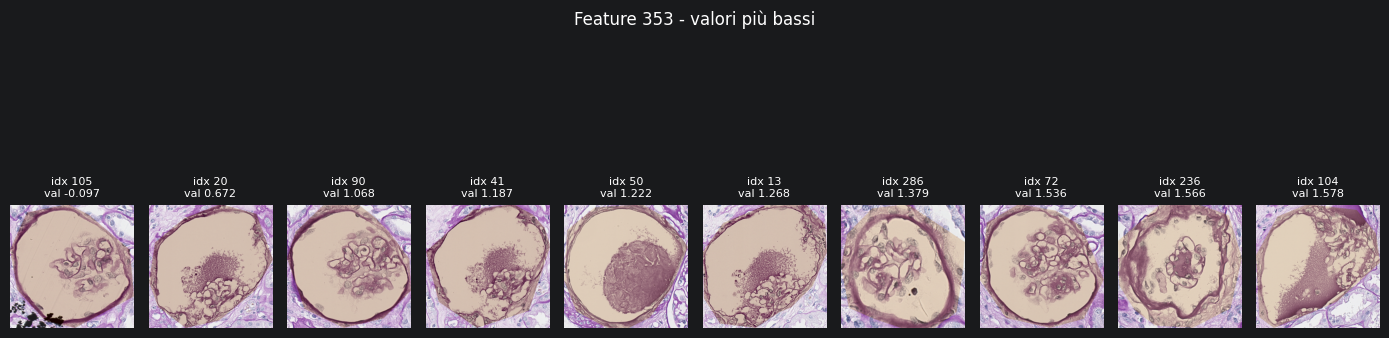

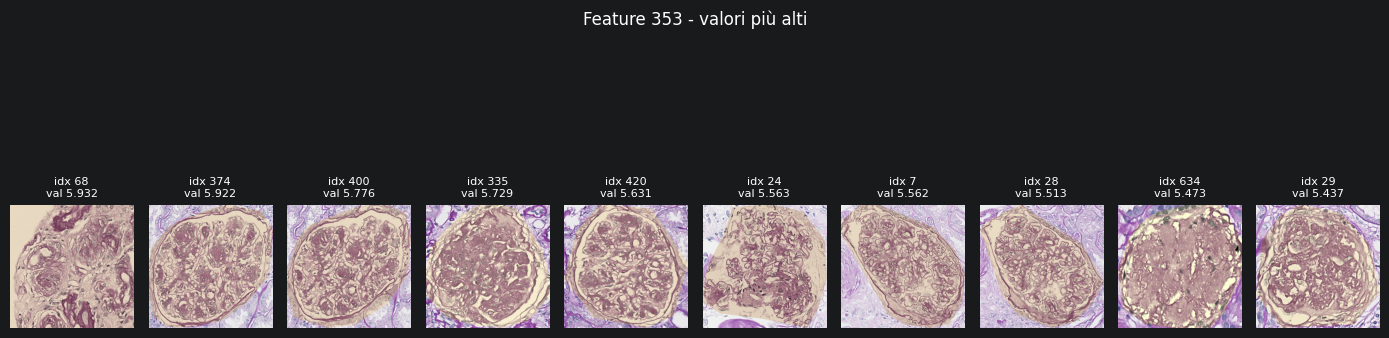

In [6]:
from pathlib import Path

masked_dir = Path("/home/pasquale/PycharmProjects/Glomeruli-FP03-2026/data/glomeruli/masked/")

image_paths = sorted(
    list(masked_dir.glob("*.png")) +
    list(masked_dir.glob("*.jpg")) +
    list(masked_dir.glob("*.jpeg")) +
    list(masked_dir.glob("*.tif")) +
    list(masked_dir.glob("*.tiff"))
)

print("Numero immagini:", len(image_paths))
print("Numero embedding:", X_emb.shape[0])

result = inspect_most_variable_feature(
    X_emb=X_emb,
    image_paths=image_paths,
    top_n=10
)

In [26]:
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

import umap
from sklearn.cluster import HDBSCAN


def evaluate_embedding_pipeline(
    X,
    name,
    pca_variance=0.95,
    umap_n_neighbors=40,
    umap_min_dist=0.1,
    umap_n_components=30,
    umap_metric="euclidean",
    hdbscan_min_cluster_size=20,
    hdbscan_min_samples=15,
    random_state=42,
):
    """
    Valuta un embedding con una pipeline fissa:
    StandardScaler -> PCA -> UMAP -> HDBSCAN.

    Ritorna un dizionario con embedding trasformati, labels e metriche.
    """

    X = np.asarray(X)

    # 1. Standardizzazione
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 2. PCA
    pca = PCA(n_components=pca_variance, random_state=random_state)
    X_pca = pca.fit_transform(X_scaled)

    # 3. UMAP
    reducer = umap.UMAP(
        n_neighbors=umap_n_neighbors,
        min_dist=umap_min_dist,
        n_components=umap_n_components,
        metric=umap_metric,
        random_state=random_state,
    )

    X_umap = reducer.fit_transform(X_pca)

    # 4. HDBSCAN
    clusterer = HDBSCAN(
        min_cluster_size=hdbscan_min_cluster_size,
        min_samples=hdbscan_min_samples,
    )

    labels = clusterer.fit_predict(X_umap)

    # 5. Metriche base
    n_samples = X.shape[0]
    noise_mask = labels == -1
    clustered_mask = labels != -1

    n_noise = np.sum(noise_mask)
    noise_ratio = n_noise / n_samples

    unique_clusters = sorted(set(labels) - {-1})
    n_clusters = len(unique_clusters)

    # Metriche calcolabili solo sui punti non-noise
    if n_clusters >= 2 and np.sum(clustered_mask) > n_clusters:
        X_eval = X_umap[clustered_mask]
        labels_eval = labels[clustered_mask]

        silhouette = silhouette_score(X_eval, labels_eval)
        davies_bouldin = davies_bouldin_score(X_eval, labels_eval)
        calinski_harabasz = calinski_harabasz_score(X_eval, labels_eval)
    else:
        silhouette = np.nan
        davies_bouldin = np.nan
        calinski_harabasz = np.nan

    result = {
        "name": name,
        "n_samples": n_samples,
        "original_dim": X.shape[1],
        "pca_dim": X_pca.shape[1],
        "pca_explained_variance": float(np.sum(pca.explained_variance_ratio_)),
        "umap_dim": X_umap.shape[1],
        "n_clusters": n_clusters,
        "noise_ratio": float(noise_ratio),
        "silhouette": float(silhouette) if not np.isnan(silhouette) else np.nan,
        "davies_bouldin": float(davies_bouldin) if not np.isnan(davies_bouldin) else np.nan,
        "calinski_harabasz": float(calinski_harabasz) if not np.isnan(calinski_harabasz) else np.nan,
        "X_scaled": X_scaled,
        "X_pca": X_pca,
        "X_umap": X_umap,
        "labels": labels,
    }

    return result

2026-06-19 10:33:20.418981: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [48]:
X_masked = np.load("/home/pasquale/PycharmProjects/Glomeruli-FP03-2026/data/glomeruli/embeddings/dinov2_large_cls_masked_embeddings.npy")
X_unmasked = np.load("/home/pasquale/PycharmProjects/Glomeruli-FP03-2026/data/glomeruli/embeddings/dinov2_large_cls_unmasked_embeddings.npy")

result_masked = evaluate_embedding_pipeline(
    X=X_masked,
    name="DINOV2 large cls masked",
    pca_variance=0.95,
    umap_n_neighbors=40,
    umap_min_dist=0.1,
    umap_n_components=30,
    hdbscan_min_cluster_size=20,
    hdbscan_min_samples=15,
    random_state=42,
)

result_unmasked = evaluate_embedding_pipeline(
    X=X_unmasked,
    name="DINOV2 large cls unmasked",
    pca_variance=0.95,
    umap_n_neighbors=40,
    umap_min_dist=0.1,
    umap_n_components=30,
    hdbscan_min_cluster_size=20,
    hdbscan_min_samples=15,
    random_state=42,
)

/home/pasquale/PycharmProjects/Glomeruli-FP03-2026/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/pasquale/PycharmProjects/Glomeruli-FP03-2026/.venv/lib64/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/home/pasquale/PycharmProjects/Glomeruli-FP03-2026/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/pasquale/PycharmProjects/Glomeruli-FP03-2026/.venv/lib64/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


In [49]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "name": result_masked["name"],
        "pca_dim": result_masked["pca_dim"],
        "n_clusters": result_masked["n_clusters"],
        "noise_ratio": result_masked["noise_ratio"],
        "silhouette": result_masked["silhouette"],
        "davies_bouldin": result_masked["davies_bouldin"],
        "calinski_harabasz": result_masked["calinski_harabasz"],
    },
    {
        "name": result_unmasked["name"],
        "pca_dim": result_unmasked["pca_dim"],
        "n_clusters": result_unmasked["n_clusters"],
        "noise_ratio": result_unmasked["noise_ratio"],
        "silhouette": result_unmasked["silhouette"],
        "davies_bouldin": result_unmasked["davies_bouldin"],
        "calinski_harabasz": result_unmasked["calinski_harabasz"],
    },
])

comparison

,name,pca_dim,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz
0,DINOV2 large cls masked,9,3,0.044313,0.532630,0.511938,1638.863284
1,DINOV2 large cls unmasked,37,2,0.311669,-0.032945,1.638138,9.402550
